# Deep Learning Lab 6: The Optimizer Zoo — From SGD to Adam

---

## 1. Lab Overview & Architecture

In deep learning, the optimizer dictates how neural network weights update based on computed gradients. When loss surfaces have uneven curvature—steep in some directions and flat in others—simple optimization algorithms struggle.

In this lab, we will use PyTorch's native `torch.optim` module to observe how each optimizer behaves on an **ill-conditioned anisotropic ravine** defined by:

$$f(w_0, w_1) = 0.5 \cdot (0.1 w_0^2 + 2.0 w_1^2)$$

* $w_0$ is the **shallow axis** (slope is gentle; requires large steps).
* $w_1$ is the **steep axis** (slope is $20\times$ steeper; prone to wild oscillations).
* The global minimum is at $(w_0, w_1) = (0.0, 0.0)$.

```text
   ┌─────────────────────────────────────────────────────────────┐
   │                    THE EVOLUTIONARY PATH                    │
   │                                                             │
   │   Plain SGD ────────► SGD + Momentum ────────► NAG          │
   │   (Oscillates)        (Builds speed)           (Brakes)     │
   │        │                                        │           │
   │        ▼                                        ▼           │
   │   AdaGrad   ────────► RMSProp        ────────► ADAM         │
   │   (Stalls out)        (Adapts strides)         (The King)   │
   └─────────────────────────────────────────────────────────────┘
```

![Ravine Image](https://drive.google.com/uc?id=1u-XFX-BEIWOWFtD0AdlXWoEK7kxdS5Q9)

## 2. Environment Setup & Visualizer
Run the cell below to set up our toy objective function and an automated PyTorch simulation runner. Instead of custom update equations, we initialize standard `torch.nn.Parameter` tensors and pass them directly to `torch.optim`.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Fix random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define the ravine loss function
def ravine_loss(w):
    return 0.5 * (0.1 * w[0]**2 + 2.0 * w[1]**2) # w is a tensor of shape (2,)

# Helper function to run native PyTorch optimizers
def track_optimizer(optimizer_cls, opt_kwargs, start_pos=[-4.5, 4.0], steps=50):
    # Create the parameter to optimize
    w = torch.tensor(start_pos, dtype=torch.float32, requires_grad=True)

    # Initialize PyTorch optimizer
    optimizer = optimizer_cls([w], **opt_kwargs)

    trajectory = [w.detach().clone().numpy()]
    loss_history = []

    for _ in range(steps):
        optimizer.zero_grad()
        loss = ravine_loss(w)
        loss.backward()
        optimizer.step()

        trajectory.append(w.detach().clone().numpy())
        loss_history.append(loss.item())

    return np.array(trajectory), loss_history

# Visualizer for 2D Contour & Trajectories
def plot_trajectories(trajectories, title):
    x = np.linspace(-5.0, 5.0, 300)
    y = np.linspace(-5.0, 5.0, 300)
    X, Y = np.meshgrid(x, y)
    Z = 0.5 * (0.1 * X**2 + 2.0 * Y**2)

    plt.figure(figsize=(9, 6))
    plt.contour(X, Y, Z, levels=35, cmap="Blues_r", alpha=0.6)

    for name, traj in trajectories.items():
        plt.plot(traj[:, 0], traj[:, 1], marker="o", markersize=3, label=name, lw=2)

    plt.scatter([0], [0], color="red", marker="*", s=250, label="Global Minimum (0,0)", zorder=10)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("$w_0$ (Gentle Axis)", fontsize=11)
    plt.ylabel("$w_1$ (Steep Axis)", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


## 3. Step-by-Step Optimizer Progression

### Step 1: Plain Stochastic Gradient Descent (SGD)

#### Theory & Intuition
Standard SGD updates parameters proportionally to the negative gradient:

$$w_{t+1} = w_t - \eta \cdot \nabla f(w_t)$$

#### The Bottleneck
Plain SGD has no memory. On an anisotropic surface, the gradient along the steep axis ($w_1$) is massive compared to the flat axis ($w_0$).
* If you set $\eta$ high, SGD bounces uncontrollably across the canyon walls.
* If you set $\eta$ low to prevent bouncing, progress along the flat valley floor crawls.

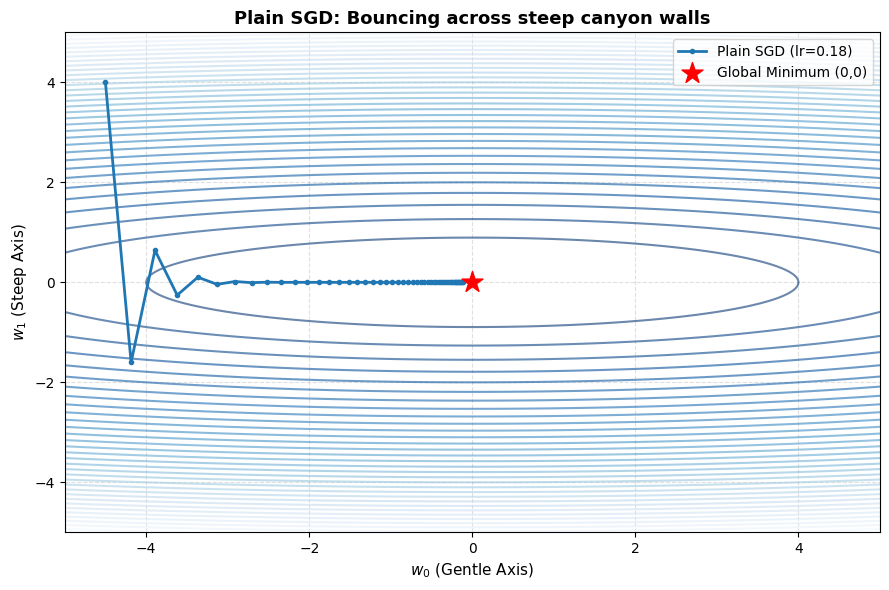

In [ ]:
# Run Plain SGD
sgd_traj, sgd_loss = track_optimizer(torch.optim.SGD, {'lr': 0.7})

plot_trajectories({"Plain SGD (lr=0.18)": sgd_traj}, "Plain SGD: Bouncing across steep canyon walls")

### Step 2: Adding Velocity — SGD + Momentum

#### Theory & Intuition
To stop the oscillation, we give the optimizer **physical inertia** (like a heavy rolling ball). We maintain a velocity vector $v_t$:

$$v_{t+1} = \beta v_t + \nabla f(w_t)$$
$$w_{t+1} = w_t - \eta \cdot v_{t+1}$$

Where $\beta \in [0, 1)$ (typically $0.9$).

#### Why It Fixes SGD
Gradients that oscillate back and forth (along $w_1$) have alternating signs and cancel out in the velocity accumulator. Gradients pointing in the same continuous direction (along $w_0$) accumulate and accelerate progress.

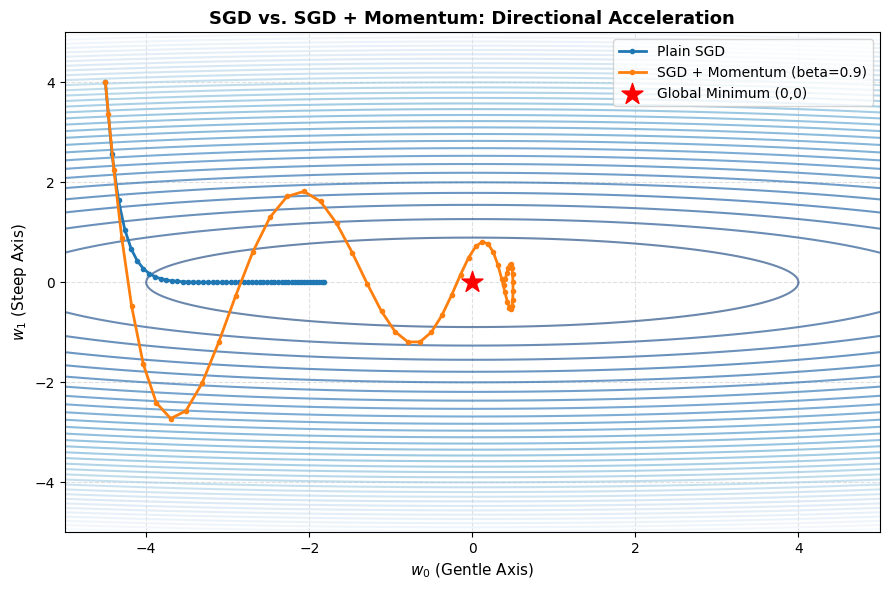

In [ ]:
# Run SGD + Momentum using native PyTorch argument
momentum_traj, momentum_loss = track_optimizer(torch.optim.SGD, {'lr': 0.08, 'momentum': 0.9})

plot_trajectories({
    "Plain SGD": sgd_traj,
    "SGD + Momentum (beta=0.9)": momentum_traj
}, "SGD vs. SGD + Momentum: Directional Acceleration")

### Step 3: Anticipating the Curve — Nesterov Accelerated Gradient (NAG)

#### Theory & Intuition
Standard momentum can build so much speed that it overshoots the valley floor before turning around.

Nesterov Momentum adds a lookahead mechanism: instead of computing the gradient at the current position $w_t$, it computes the gradient at the *projected future position* $w_t - \eta \beta v_t$.

$$\text{Gradient computed at: } w_{\text{lookahead}} = w_t - \eta \beta v_t$$

If the momentum is about to carry the parameter up a steep wall, the lookahead gradient detects this early and applies a braking force.

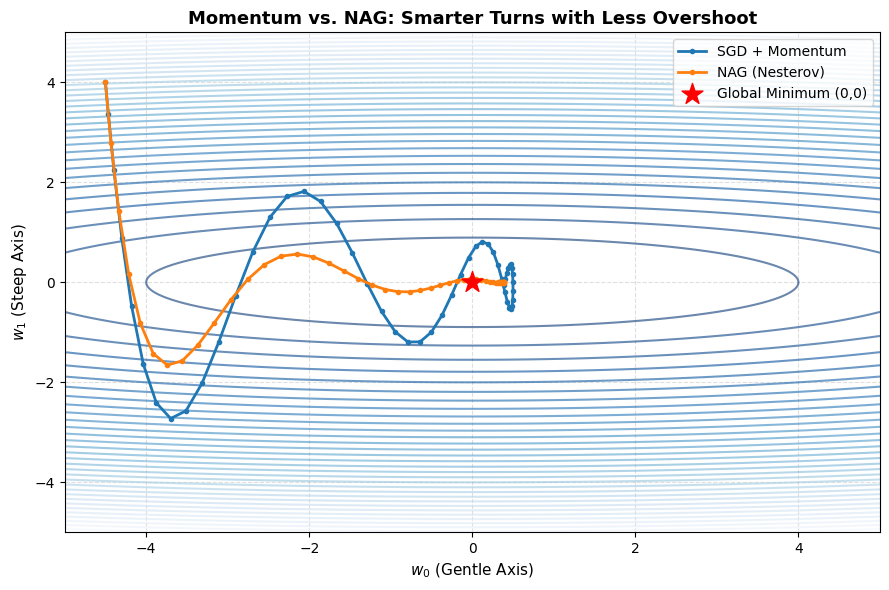

In [ ]:
# Run Nesterov Accelerated Gradient via PyTorch
nag_traj, nag_loss = track_optimizer(torch.optim.SGD, {'lr': 0.08, 'momentum': 0.9, 'nesterov': True})

plot_trajectories({
    "SGD + Momentum": momentum_traj,
    "NAG (Nesterov)": nag_traj
}, "Momentum vs. NAG: Smarter Turns with Less Overshoot")

### Step 4: Adaptive Step Sizes — AdaGrad

#### Theory & Intuition
Momentum uses the exact same learning rate scale for every single coordinate. What if steep coordinates received smaller learning rates and flat coordinates received larger learning rates?

AdaGrad accumulates the sum of squared past gradients $G_t$ for each coordinate:

$$G_{t+1} = G_t + (\nabla f(w_t))^2$$
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{G_{t+1}} + \epsilon} \odot \nabla f(w_t)$$

#### The Bottleneck
Because $(\nabla f(w_t))^2 \ge 0$, $G_t$ monotonically increases with every single step. The effective learning rate continuously shrinks until the optimizer completely stalls before reaching the minimum.

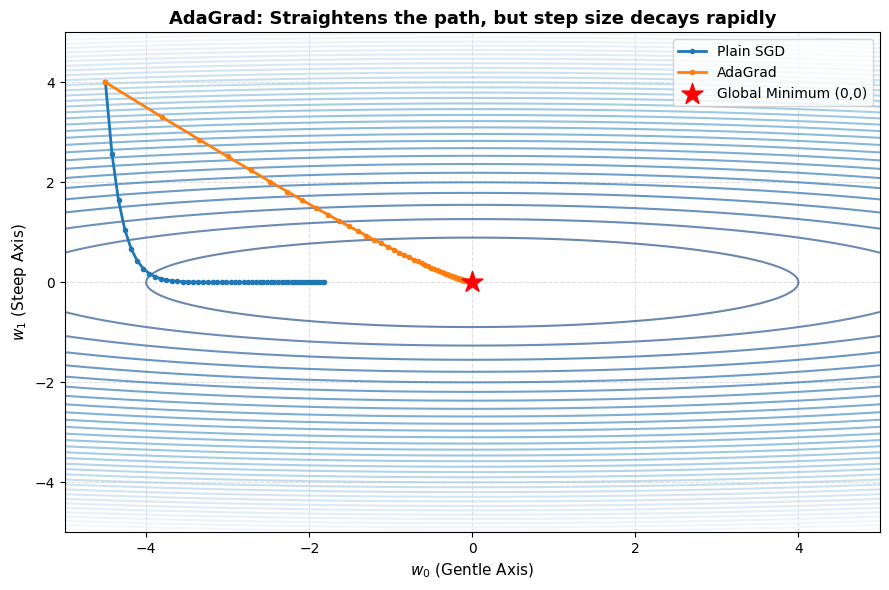

In [ ]:
# Run AdaGrad
adagrad_traj, adagrad_loss = track_optimizer(torch.optim.Adagrad, {'lr': 0.7})

plot_trajectories({
    "Plain SGD": sgd_traj,
    "AdaGrad": adagrad_traj
}, "AdaGrad: Straightens the path, but step size decays rapidly")

### Step 5: Fixing the Decay — RMSProp

#### Theory & Intuition
Geoffrey Hinton proposed replacing AdaGrad's infinite sum with an **exponentially decaying moving average** of squared gradients:

$$v_{t+1} = \alpha v_t + (1 - \alpha)(\nabla f(w_t))^2$$
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{v_{t+1}} + \epsilon} \odot \nabla f(w_t)$$

#### Why It Fixes AdaGrad
RMSProp only "remembers" recent gradients (governed by $\alpha$, typically $0.9$ or $0.99$). The denominator no longer grows infinitely, allowing the optimizer to keep moving without stalling.

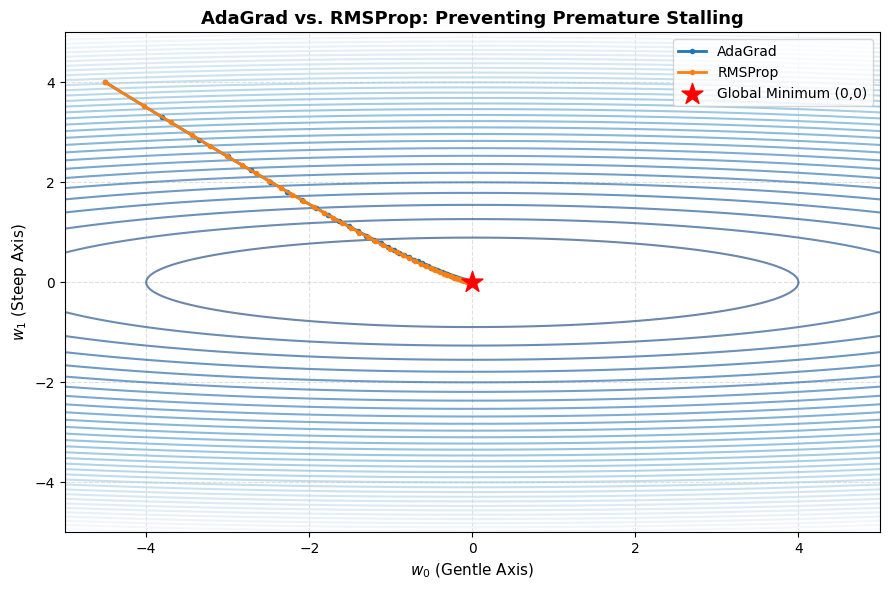

In [ ]:
# Run RMSProp
rmsprop_traj, rmsprop_loss = track_optimizer(torch.optim.RMSprop, {'lr': 0.15, 'alpha': 0.9})

plot_trajectories({
    "AdaGrad": adagrad_traj,
    "RMSProp": rmsprop_traj
}, "AdaGrad vs. RMSProp: Preventing Premature Stalling")

### Step 6: Combining Momentum & Adaptive Scales — Adam

#### Theory & Intuition
**Adaptive Moment Estimation (Adam)** merges the best aspects of Momentum and RMSProp:
1. **First Moment ($m_t$):** Moving average of gradients (Momentum / Velocity).
2. **Second Moment ($v_t$):** Moving average of squared gradients (RMSProp / Adaptive scaling).
3. **Bias Correction:** Normalizes $m_t$ and $v_t$ during early iterations when they are biased toward zero.

$$m_{t+1} = \beta_1 m_t + (1 - \beta_1) g_t \quad \implies \quad \hat{m}_{t+1} = \frac{m_{t+1}}{1 - \beta_1^{t+1}}$$
$$v_{t+1} = \beta_2 v_t + (1 - \beta_2) g_t^2 \quad \implies \quad \hat{v}_{t+1} = \frac{v_{t+1}}{1 - \beta_2^{t+1}}$$
$$w_{t+1} = w_t - \frac{\eta}{\sqrt{\hat{v}_{t+1}} + \epsilon} \hat{m}_{t+1}$$

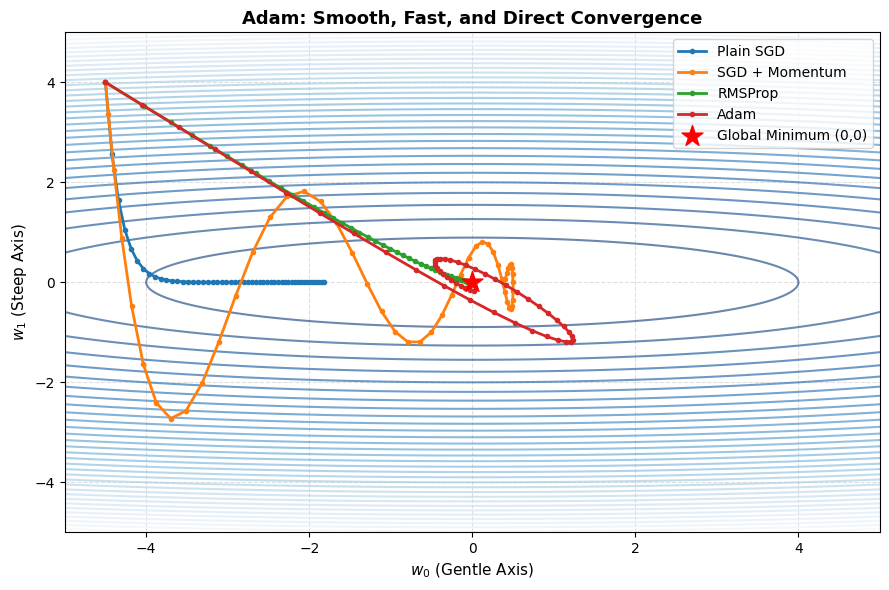

In [ ]:
# Run Adam
adam_traj, adam_loss = track_optimizer(torch.optim.Adam, {'lr': 0.45, 'betas': (0.9, 0.999)})

plot_trajectories({
    "Plain SGD": sgd_traj,
    "SGD + Momentum": momentum_traj,
    "RMSProp": rmsprop_traj,
    "Adam": adam_traj
}, "Adam: Smooth, Fast, and Direct Convergence")

## 4. The Grand Showdown (All Optimizers)
Run this comparison block to view the full convergence path and the loss curve over time for all six optimizers on the exact same surface.

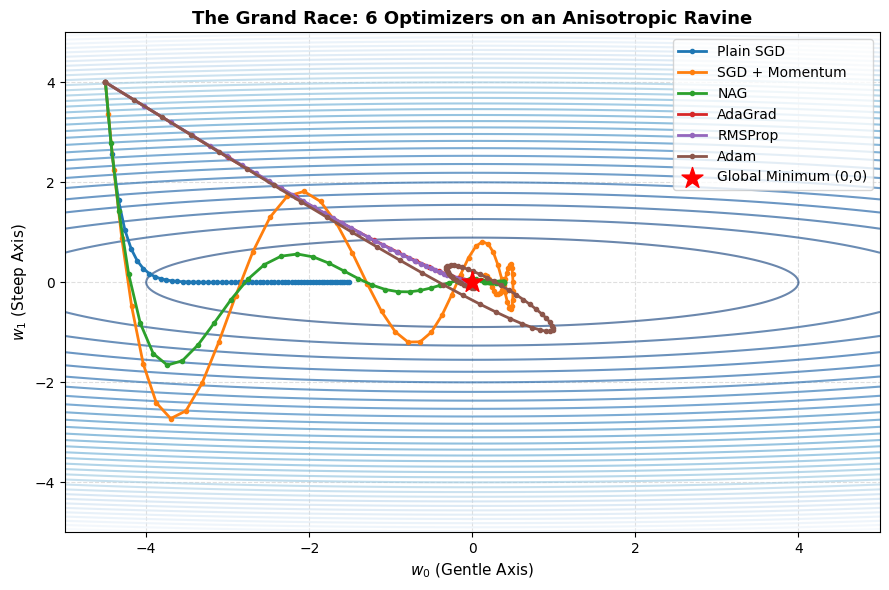

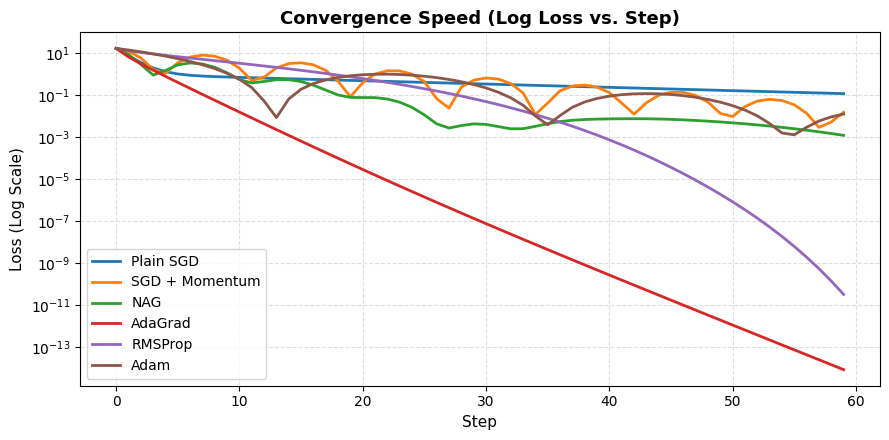

In [ ]:
optimizers_config = {
    "Plain SGD": (torch.optim.SGD, {'lr': 0.18}),
    "SGD + Momentum": (torch.optim.SGD, {'lr': 0.08, 'momentum': 0.9}),
    "NAG": (torch.optim.SGD, {'lr': 0.08, 'momentum': 0.9, 'nesterov': True}),
    "AdaGrad": (torch.optim.Adagrad, {'lr': 1.5}),
    "RMSProp": (torch.optim.RMSprop, {'lr': 0.15, 'alpha': 0.9}),
    "Adam": (torch.optim.Adam, {'lr': 0.35, 'betas': (0.9, 0.999)})
}

all_trajectories = {}
all_losses = {}

for name, (opt_cls, kwargs) in optimizers_config.items():
    traj, loss = track_optimizer(opt_cls, kwargs, steps=60)
    all_trajectories[name] = traj
    all_losses[name] = loss

# 1. Trajectory Plot
plot_trajectories(all_trajectories, "The Grand Race: 6 Optimizers on an Anisotropic Ravine")

# 2. Loss Convergence Curves
plt.figure(figsize=(9, 4.5))
for name, loss_hist in all_losses.items():
    plt.plot(loss_hist, label=name, lw=2)

plt.yscale('log')
plt.title("Convergence Speed (Log Loss vs. Step)", fontsize=13, fontweight='bold')
plt.xlabel("Step", fontsize=11)
plt.ylabel("Loss (Log Scale)", fontsize=11)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

### A Note on the Results: Why Doesn't Adam Win Here?

Looking at the final loss values above, you'll notice **Adam is not the top performer** — AdaGrad and RMSProp actually reach the lowest loss, with Adam trailing behind even Nesterov (NAG):

| Optimizer | Final Loss (≈) |
|---|---|
| AdaGrad | ~1e-15 |
| RMSProp | ~1e-12 |
| NAG | ~1e-3 |
| **Adam** | ~1.5e-2 |
| SGD + Momentum | ~2.5e-2 |
| Plain SGD | ~1.1e-1 |

This isn't a bug — it's a genuine property of *this specific toy problem*, and it's worth understanding why.

**The ravine we've been optimizing is a pure, noise-free, convex quadratic bowl.** This is about the friendliest landscape an optimizer can face: the gradient always points in a consistent, predictable direction, and it shrinks smoothly and monotonically as you approach the minimum.

On a landscape like this, AdaGrad's biggest "weakness" — its ever-shrinking, monotonically-decaying learning rate — actually becomes a strength. As it nears $(0,0)$, its accumulated denominator naturally anneals the step size to near-zero, letting it land almost exactly on the minimum with no overshoot. RMSProp benefits similarly. NAG's curvature-aware lookahead is also extremely well-matched to a smooth quadratic, since there's nothing unpredictable about the gradient for it to "anticipate" — it's honestly close to the theoretically ideal accelerated method for this exact setting.

**Adam, by contrast, was designed for a much harder regime:** noisy, non-stationary gradients from mini-batch sampling, and high-dimensional, non-convex loss surfaces where the curvature changes from region to region. Its moving averages and bias correction — the very things that make it so robust in real deep learning training — add a bit of extra "lag" that isn't needed here, since there's no noise to smooth out and no changing curvature to adapt to.

**Takeaway:** Adam being called "the king" of optimizers refers to its *consistency and robustness across the messy, noisy, non-convex loss landscapes typical of real neural network training* — not that it dominates on every possible problem. On simple, deterministic, convex toys like this one, classical adaptive or momentum-based methods can legitimately out-race it. You'll see Adam's real advantage much more clearly in the saddle-point mini-challenge below, where the landscape stops being convex.

## 5. Summary Cheat-Sheet

| Optimizer | Core Mechanism | Primary Advantage | Typical Weakness |
| :--- | :--- | :--- | :--- |
| **SGD** | $w \leftarrow w - \eta g$ | Simple baseline | Heavy oscillations in ravines |
| **SGD + Momentum** | Adds velocity $v \leftarrow \beta v + g$ | Cancels oscillations, speeds up flat directions | Can overshoot turns |
| **NAG** | Computes gradient at lookahead point | Reduces overshooting | Still single global learning rate |
| **AdaGrad** | Divides by $\sqrt{\sum g^2}$ | Automatic per-parameter step sizes | Learning rate decays to zero |
| **RMSProp** | Exponential moving average of $g^2$ | Solves AdaGrad's vanishing learning rate | Can struggle without directional momentum |
| **Adam** | Momentum (1st moment) + RMSProp (2nd moment) | Fast, robust across various architectures | Can occasionally generalize worse than tuned SGD |

---

## 6. Mini-Challenge: Taming the Non-Convex Saddle Point

A saddle point is flat at the center, but curves up in one direction and down in another.
Consider the saddle-point loss function:

$$f(w_0, w_1) = 0.2 w_0^2 - 0.5 w_1^2$$

Starting from position `[-2.0, 0.01]`, plain SGD often gets stuck or crawls near the saddle point $(0,0)$.

**Task:** Complete the boilerplate code below to run **Plain SGD** and **Adam** on this saddle surface for 40 steps, and plot both trajectories.

In [ ]:
def saddle_loss(w):
    return 0.2 * w[0]**2 - 0.5 * w[1]**2

def run_saddle_challenge():
    start = [-2.0, 0.01]

    # TODO 1: Run SGD with lr=0.1 on saddle_loss (hint: you may need to write a custom track loop or modify the one above)
    # sgd_traj, _ = track_optimizer(...)

    # TODO 2: Run Adam with lr=0.2 on saddle_loss
    # adam_traj, _ = track_optimizer(...)

    # TODO 3: Plot and observe who escapes the saddle faster
    pass

# run_saddle_challenge()

### Challenge Solution (Expand cell below)

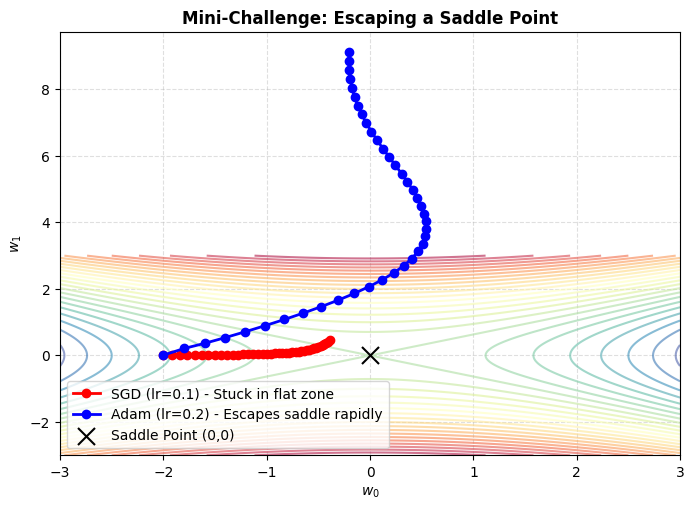

In [ ]:
def saddle_loss(w):
    return 0.2 * w[0]**2 - 0.5 * w[1]**2

# Custom runner for saddle function
def track_saddle(optimizer_cls, opt_kwargs, start_pos=[-2.0, 0.01], steps=40):
    w = torch.tensor(start_pos, dtype=torch.float32, requires_grad=True)
    optimizer = optimizer_cls([w], **opt_kwargs)
    trajectory = [w.detach().clone().numpy()]

    for _ in range(steps):
        optimizer.zero_grad()
        loss = saddle_loss(w)
        loss.backward()
        optimizer.step()
        trajectory.append(w.detach().clone().numpy())

    return np.array(trajectory)

# Run both optimizers
sgd_saddle = track_saddle(torch.optim.SGD, {'lr': 0.1})
adam_saddle = track_saddle(torch.optim.Adam, {'lr': 0.2})

# Plot saddle trajectories
x = np.linspace(-3.0, 3.0, 200)
y = np.linspace(-3.0, 3.0, 200)
X, Y = np.meshgrid(x, y)
Z = 0.2 * X**2 - 0.5 * Y**2

plt.figure(figsize=(8, 5.5))
plt.contour(X, Y, Z, levels=30, cmap="Spectral", alpha=0.6)
plt.plot(sgd_saddle[:, 0], sgd_saddle[:, 1], 'ro-', label="SGD (lr=0.1) - Stuck in flat zone", lw=2)
plt.plot(adam_saddle[:, 0], adam_saddle[:, 1], 'bo-', label="Adam (lr=0.2) - Escapes saddle rapidly", lw=2)
plt.scatter([0], [0], color="black", marker="x", s=150, label="Saddle Point (0,0)", zorder=5)

plt.title("Mini-Challenge: Escaping a Saddle Point", fontsize=12, fontweight='bold')
plt.xlabel("$w_0$")
plt.ylabel("$w_1$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()